# Aufgabe 2

In [31]:
import math
import matplotlib.pyplot as plt
import numpy as np
from skimage.io import imread

In [32]:
# Bilder laden
bild1 = imread('bildverbesserung/bild1.png')
bild2 = imread('bildverbesserung/bild2.png')

## 2.1

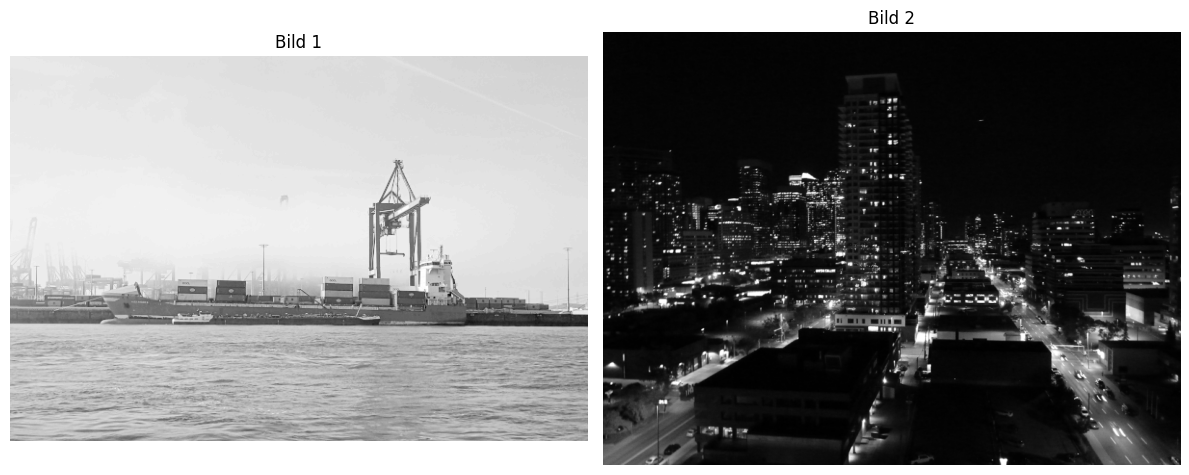

In [33]:
# Bilder visualisieren
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].imshow(bild1, cmap='gray')
axes[0].set_title('Bild 1')
axes[0].axis('off')

axes[1].imshow(bild2, cmap='gray')
axes[1].set_title('Bild 2')
axes[1].axis('off')

plt.tight_layout()
plt.show()

In [34]:
# Normierte Histogramme berechnen
# Mit 256 Behältern (für 8-Bit Grauwerte)
hist1, bin_edges1 = np.histogram(bild1, bins=256, range=(0, 256))
hist2, bin_edges2 = np.histogram(bild2, bins=256, range=(0, 256))

# Normieren: Histogramm durch die Gesamtzahl der Pixel teilen
hist1_norm = hist1 / bild1.size
hist2_norm = hist2 / bild2.size

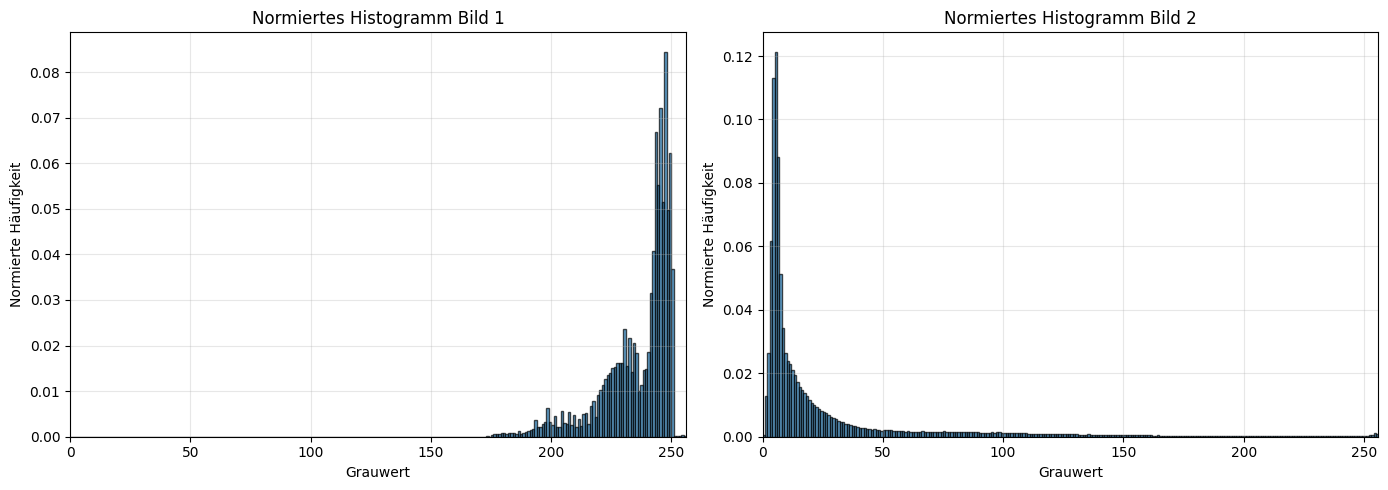

In [35]:
# Histogramme plotten
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogramm 1
bin_centers1 = bin_edges1[:-1]
axes[0].bar(bin_centers1, hist1_norm, width=1, align='edge', edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Grauwert')
axes[0].set_ylabel('Normierte Häufigkeit')
axes[0].set_title('Normiertes Histogramm Bild 1')
axes[0].set_xlim(0, 256)
axes[0].grid(True, alpha=0.3)

# Histogramm 2
bin_centers2 = bin_edges2[:-1]
axes[1].bar(bin_centers2, hist2_norm, width=1, align='edge', edgecolor='black', alpha=0.7)
axes[1].set_xlabel('Grauwert')
axes[1].set_ylabel('Normierte Häufigkeit')
axes[1].set_title('Normiertes Histogramm Bild 2')
axes[1].set_xlim(0, 256)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 2.2

In [36]:
# Histogrammmausgleich implementieren
def histogram_equalization(img):
    """Histogrammmausgleich nach der Formel aus der Vorlesung"""
    # Normiertes Histogramm berechnen
    hist, _ = np.histogram(img, bins=256, range=(0, 256))
    hist_norm = hist / img.size
    
    T = np.round(255 * np.cumsum(hist_norm)).astype(np.uint8)
    
    # Transformationsfunktion auf Bild anwenden
    img_equalized = T[img]
    return img_equalized

# Histogrammmausgleich auf beide Bilder anwenden
bild1_eq = histogram_equalization(bild1)
bild2_eq = histogram_equalization(bild2)

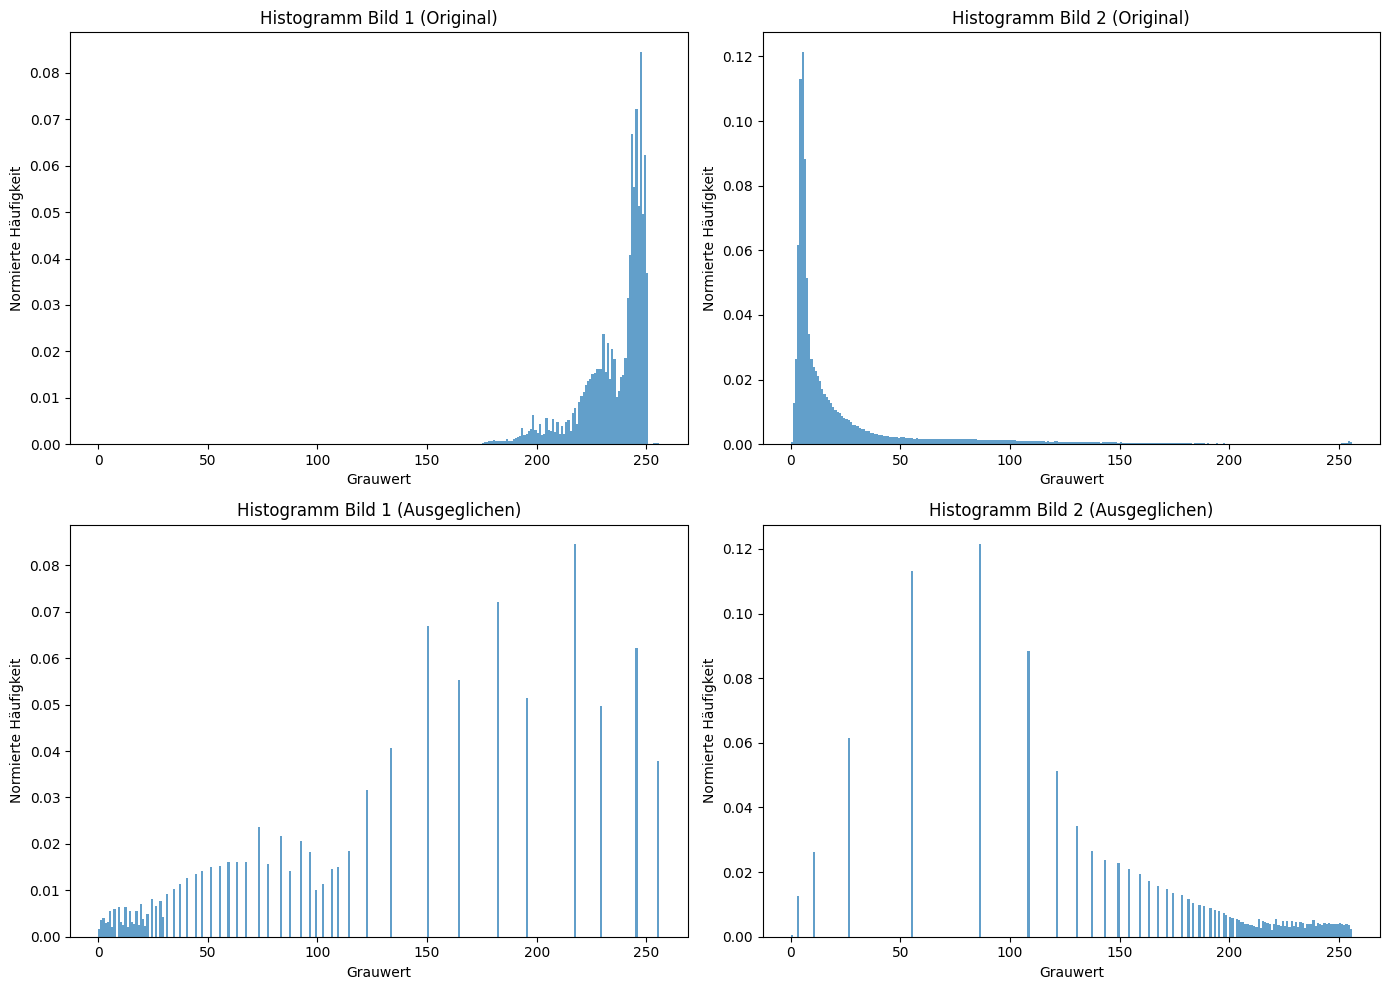

In [37]:
# Histogramme der ausgeglichenen Bilder berechnen und plotten
hist1_eq, bin_edges1_eq = np.histogram(bild1_eq, bins=256, range=(0, 256))
hist2_eq, bin_edges2_eq = np.histogram(bild2_eq, bins=256, range=(0, 256))
hist1_eq_norm = hist1_eq / bild1_eq.size
hist2_eq_norm = hist2_eq / bild2_eq.size

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Originale Histogramme
axes[0, 0].bar(bin_edges1[:-1], hist1_norm, width=1, align='edge', alpha=0.7)
axes[0, 0].set_title('Histogramm Bild 1 (Original)')

axes[0, 1].bar(bin_edges2[:-1], hist2_norm, width=1, align='edge', alpha=0.7)
axes[0, 1].set_title('Histogramm Bild 2 (Original)')

# Ausgeglichene Histogramme
axes[1, 0].bar(bin_edges1_eq[:-1], hist1_eq_norm, width=1, align='edge', alpha=0.7)
axes[1, 0].set_title('Histogramm Bild 1 (Ausgeglichen)')

axes[1, 1].bar(bin_edges2_eq[:-1], hist2_eq_norm, width=1, align='edge', alpha=0.7)
axes[1, 1].set_title('Histogramm Bild 2 (Ausgeglichen)')

for ax in axes.flat:
    ax.set_ylabel('Normierte Häufigkeit')
    ax.set_xlabel('Grauwert')

plt.tight_layout()
plt.show()

Die Grauwerte sind nach der Transformation besser über den gesamten Bereich verteilt.

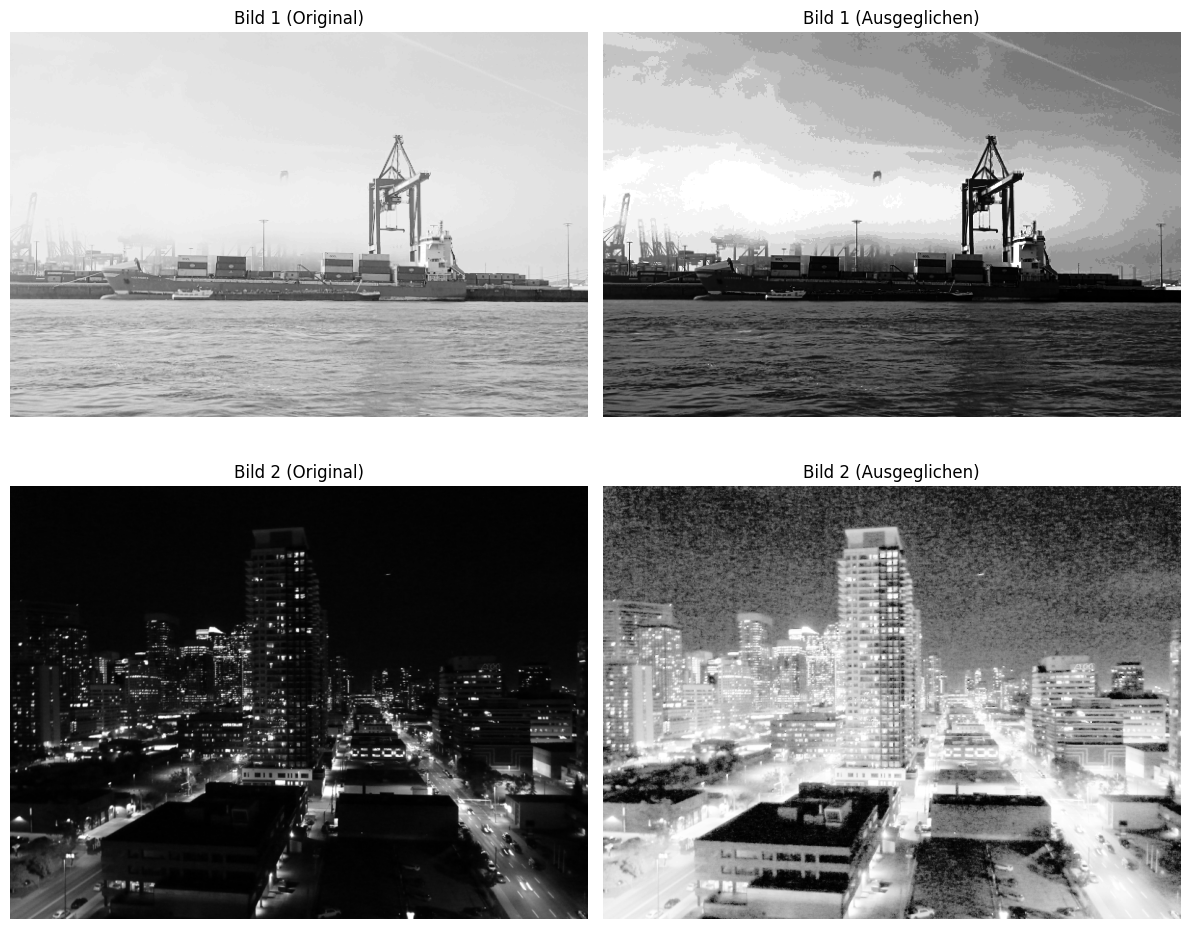

In [38]:
# Bilder vorher und nachher visualisieren
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

axes[0, 0].imshow(bild1, cmap='gray')
axes[0, 0].set_title('Bild 1 (Original)')
axes[0, 0].axis('off')

axes[0, 1].imshow(bild1_eq, cmap='gray')
axes[0, 1].set_title('Bild 1 (Ausgeglichen)')
axes[0, 1].axis('off')

axes[1, 0].imshow(bild2, cmap='gray')
axes[1, 0].set_title('Bild 2 (Original)')
axes[1, 0].axis('off')

axes[1, 1].imshow(bild2_eq, cmap='gray')
axes[1, 1].set_title('Bild 2 (Ausgeglichen)')
axes[1, 1].axis('off')

plt.tight_layout()
plt.show()

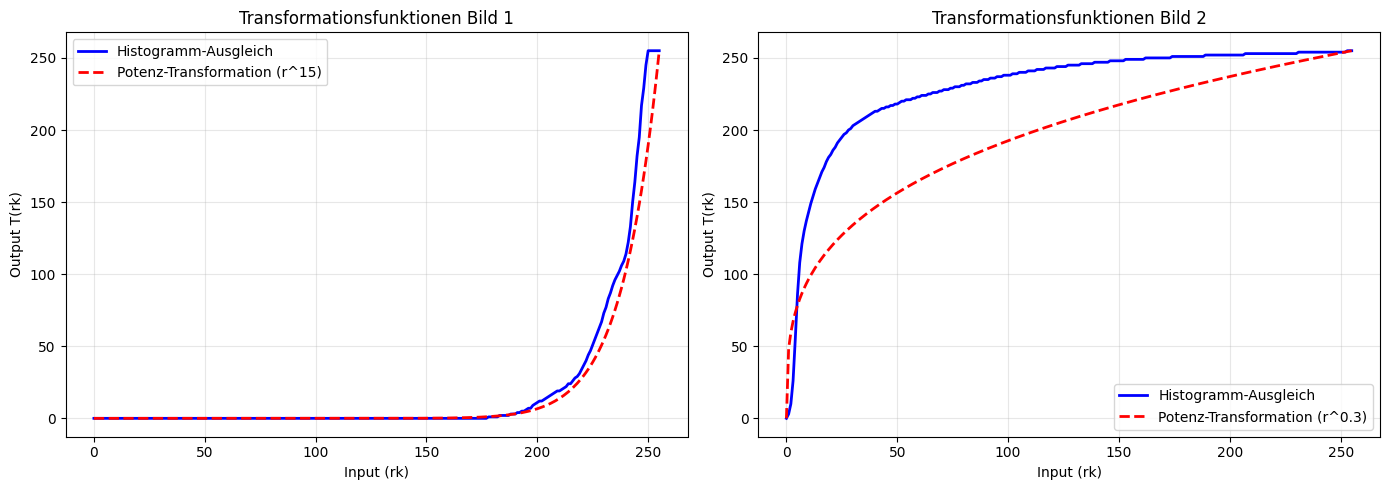

Histogramm-Ausgleich: Ähnliche Verteilung bei Bild 1, aber weniger aggressiv bei Bild 2
Potenz-Transformation: Nicht-lineare Kurven, angepasst an spezifische Kontrastverstärkung


In [39]:
## 2.3
# Transformationsfunktionen visualisieren

# Berechne T(rk) für beide Bilder
hist1_norm_calc = np.histogram(bild1, bins=256, range=(0, 256))[0] / bild1.size
hist2_norm_calc = np.histogram(bild2, bins=256, range=(0, 256))[0] / bild2.size

T_eq1 = np.round(255 * np.cumsum(hist1_norm_calc)).astype(np.uint8)
T_eq2 = np.round(255 * np.cumsum(hist2_norm_calc)).astype(np.uint8)

# Intensitätstransformationen aus Aufgabe 1 von Blatt 4
r = np.arange(0, 256)
T_pow1 = 255 * (r / 255) ** 15  # Bild 1
T_pow2 = 255 * (r / 255) ** 0.3  # Bild 2

# Transformationsfunktionen plotten
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(r, T_eq1, 'b-', label='Histogramm-Ausgleich', linewidth=2)
axes[0].plot(r, T_pow1, 'r--', label='Potenz-Transformation (r^15)', linewidth=2)
axes[0].set_xlabel('Input (rk)')
axes[0].set_ylabel('Output T(rk)')
axes[0].set_title('Transformationsfunktionen Bild 1')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(r, T_eq2, 'b-', label='Histogramm-Ausgleich', linewidth=2)
axes[1].plot(r, T_pow2, 'r--', label='Potenz-Transformation (r^0.3)', linewidth=2)
axes[1].set_xlabel('Input (rk)')
axes[1].set_ylabel('Output T(rk)')
axes[1].set_title('Transformationsfunktionen Bild 2')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Histogramm-Ausgleich: Ähnliche Verteilung bei Bild 1, aber weniger aggressiv bei Bild 2")
print("Potenz-Transformation: Nicht-lineare Kurven, angepasst an spezifische Kontrastverstärkung")